
K_R1s(r) =
-156.7246 * exp(-19.1350 r)
-4.9030 * exp(-31.5250 r)
-80.9680 * r * exp(-16.4986 r)
-0.2637 * r * exp(-7.6741 r)
-0.4527 * r^2 * exp(-6.6851 r)
-0.1057 * r^2 * exp(-4.0410 r)
-0.0278 * r^2 * exp(-2.6692 r)
-0.0098 * r^3 * exp(-2.5979 r)
-0.0000 * r^3 * exp(-0.5620 r)
-0.0001 * r^3 * exp(-1.2902 r)
+0.0000 * r^3 * exp(-0.7664 r)

K_R2s(r) =
+46.2243 * exp(-19.1350 r)
+0.1947 * exp(-31.5250 r)
+187.9933 * r * exp(-16.4986 r)
-179.3372 * r * exp(-7.6741 r)
-62.8234 * r^2 * exp(-6.6851 r)
-0.0330 * r^2 * exp(-4.0410 r)
-0.0922 * r^2 * exp(-2.6692 r)
-0.0271 * r^3 * exp(-2.5979 r)
+0.0000 * r^3 * exp(-0.5620 r)
-0.0002 * r^3 * exp(-1.2902 r)
+0.0000 * r^3 * exp(-0.7664 r)

K_R3s(r) =
+15.5136 * exp(-19.1350 r)
-0.2336 * exp(-31.5250 r)
+63.5794 * r * exp(-16.4986 r)
-63.1963 * r * exp(-7.6741 r)
-69.5197 * r^2 * exp(-6.6851 r)
+24.5288 * r^2 * exp(-4.0410 r)
+8.5411 * r^2 * exp(-2.6692 r)
+0.8066 * r^3 * exp(-2.5979 r)
+0.0000 * r^3 * exp(-0.5620 r)
+0.0069 * r^3 * exp(-1.2902 

/tmp/ipykernel_1102/2104662189.py:118: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 1.0013455388879997
Norm 2s = 1.0018535810123352
Norm 2p = 1.0000145750966165
Norm 3s = 0.9999879340238562
Norm 3p = 0.9999663757224737
Norm 4s = 0.994843695572211
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.046833       1.874423e-01       5.697566e-01   
1       0.05           0.046831       1.873738e-01       5.677156e-01   
2       0.10           0.046826       1.871676e-01       5.616769e-01   
3       0.15           0.046818       1.868227e-01       5.518619e-01   
4       0.20           0.046806       1.863379e-01       5.385615e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000002       1.558865e-07       1.689077e-08   
1997   99.85           0.000002       1.554292e-07       1.684109e-08   
1998   99.90           0.000002       1.549735e-07       1.679158e-08   
1999   99.95           0.000002       1.545193e-07       1.674224e-08   
2000  100.00           0

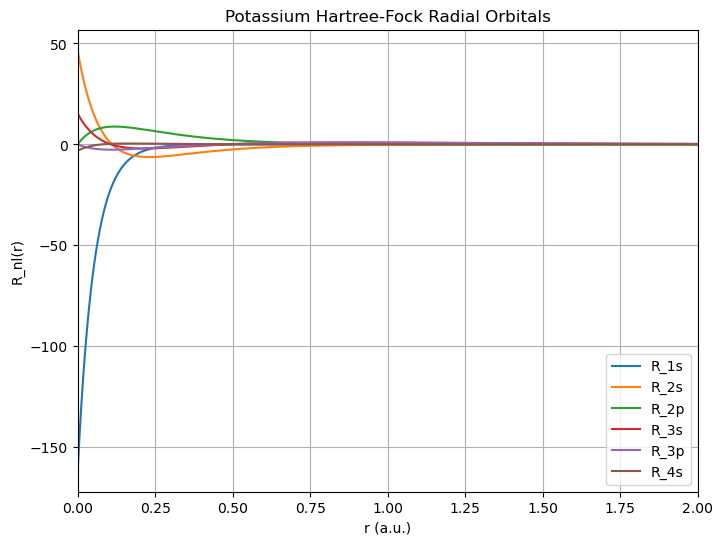

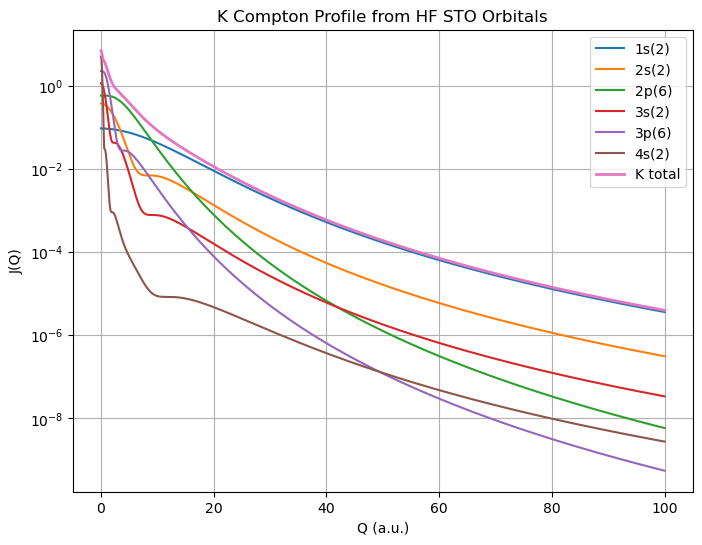

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Potassium Hartree-Fock data
# K: 1s2 2s2 2p6 3s2 3p6 4s1
# Format: (n_j, Z_j, C_j)
# =====================================================

potassium_1s = [
    (1, 19.13500, -0.936191),
    (1, 31.52500, -0.013850),
    (2, 16.49860, -0.063420),
    (2,  7.67410, -0.001400),
    (3,  6.68508, -0.001390),
    (3,  4.04102, -0.001890),
    (3,  2.66919, -0.002120),
    (4,  2.59794, -0.001180),
    (4,  0.56203, -0.000050),
    (4,  1.29017, -0.000150),
    (4,  0.76641,  0.000110),
]

potassium_2s = [
    (1, 19.13500,  0.276120),
    (1, 31.52500,  0.000550),
    (2, 16.49860,  0.147250),
    (2,  7.67410, -0.951990),
    (3,  6.68508, -0.192890),
    (3,  4.04102, -0.000590),
    (3,  2.66919, -0.007040),
    (4,  2.59794, -0.003270),
    (4,  0.56203,  0.000160),
    (4,  1.29017, -0.000450),
    (4,  0.76641,  0.000330),
]

potassium_3s = [
    (1, 19.13500,  0.092670),
    (1, 31.52500, -0.000660),
    (2, 16.49860,  0.049800),
    (2,  7.67410, -0.335470),
    (3,  6.68508, -0.213450),
    (3,  4.04102,  0.438550),
    (3,  2.66919,  0.652000),
    (4,  2.59794,  0.097490),
    (4,  0.56203,  0.005600),
    (4,  1.29017,  0.019320),
    (4,  0.76641, -0.011610),
]

potassium_4s = [
    (1, 19.13500, -0.018250),
    (1, 31.52500, -0.000310),
    (2, 16.49860,  0.008990),
    (2,  7.67410,  0.063500),
    (3,  6.68508, -0.050150),
    (3,  4.04102,  0.113460),
    (3,  2.66919, -0.114740),
    (4,  2.59794, -0.030650),
    (4,  0.56203,  0.051900),
    (4,  1.29017,  0.334310),
    (4,  0.76641,  0.704170),
]

potassium_2p = [
    (2,  8.64187,  0.667430),
    (2, 15.19360,  0.042070),
    (3,  6.91359,  0.347520),
    (3,  3.26183,  0.013980),
    (3,  2.00984, -0.009440),
    (3,  1.68876,  0.005260),
]

potassium_3p = [
    (2,  8.64187, -0.207970),
    (2, 15.19360, -0.011760),
    (3,  6.91359, -0.127440),
    (3,  3.26183,  0.567180),
    (3,  2.00984,  0.452730),
    (3,  1.68876,  0.093400),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, potassium_1s)
R2s = R_nl(r, potassium_2s)
R3s = R_nl(r, potassium_3s)
R4s = R_nl(r, potassium_4s)

R2p = R_nl(r, potassium_2p)
R3p = R_nl(r, potassium_3p)

print_R_formula(potassium_1s, "K_R1s")
print_R_formula(potassium_2s, "K_R2s")
print_R_formula(potassium_3s, "K_R3s")
print_R_formula(potassium_4s, "K_R4s")
print_R_formula(potassium_2p, "K_R2p")
print_R_formula(potassium_3p, "K_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)

chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)

I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 4s =", np.trapezoid(I_4s, p))

# K:1s2 2s2 2p6 3s2 3p6 4s1
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 1*J_4s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_4s_one_electron": J_4s,
    "J_total_K": J_total
    })
print(table)
table.to_csv("K1_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Potassium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")

plt.plot(Q, J_total, label="K total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("K Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()